# Image Stitching

Your code will take as input two color images `im_a` and `im_b` (np.ndarray with dtype np.uint8 and shape `(3, H, W)`), depicting the same scene from two different perspectives.

You then need to:

- Manually identify (at least) four corresponding pairs of points
- Estimate the homography between the first and the second image using the detected point pairs.
- Warp the second image using the estimated transformation matrix.
- "Merge" the two images in a single one by sticking one on top of the other.

The code is expected to show the final result using pyplot (e.g. calling the imshow function). When doing this, pay attention to the axis order (their format is `(W, H, 3)`).

If you employ OpenCV functions, recall that the OpenCV format is `(W, H, 3)`.



In [28]:
import torch
import numpy as np
import cv2
from skimage import data

im_a = cv2.imread("img/gallery_0.jpg", cv2.IMREAD_COLOR)
im_a = np.swapaxes(np.swapaxes(im_a, 0, 2), 1, 2)
im_a = im_a[::-1, :, :]  # from BGR to RGB


im_b = cv2.imread("img/gallery_1.jpg", cv2.IMREAD_COLOR)
im_b = np.swapaxes(np.swapaxes(im_b, 0, 2), 1, 2)
im_b = im_b[::-1, :, :]  # from BGR to RGB

In [ ]:
def image_stitching(im_a, im_b):
    # im_a and im_b are in (3, H, W) CHW format
    c1, h1, w1 = im_a.shape
    c2, h2, w2 = im_b.shape
    
    # Convert to HWC format for cv2 functions (cv2 expects H, W, C)
    im_a_hwc = np.transpose(im_a, (1, 2, 0)).astype(np.uint8)
    im_b_hwc = np.transpose(im_b, (1, 2, 0)).astype(np.uint8)

    # Manually identify (at least) four corresponding pairs of points
    point_a = np.array([[193, 33], [317, 94], [310, 210], [181, 239]], dtype=np.float32)
    point_b = np.array([[138, 50], [340, 58], [334, 199], [131, 191]], dtype=np.float32)
    
    # CORREZIONE: Stima l'omografia dall'immagine B (source) all'immagine A (destination)
    H, mask = cv2.findHomography(point_b, point_a)

    # Warp the second image using the estimated transformation matrix.
    panorama_w = w1
    panorama_h = h1 + h2
    
    # Ora il warp posizionerà i pixel di B nel sistema di coordinate di A
    im_warped = cv2.warpPerspective(im_b_hwc, H, (panorama_w, panorama_h))

    # "Merge" the two images in a single one by sticking one on top of the other.
    im_panorama = im_warped.copy()
    
    # Sovrascriviamo l'angolo in alto a sinistra con l'immagine A originale
    im_panorama[:h1, :w1] = im_a_hwc

    # Convert back to CHW format
    im_panorama_chw = np.transpose(im_panorama, (2, 0, 1))
    
    return im_panorama_chw

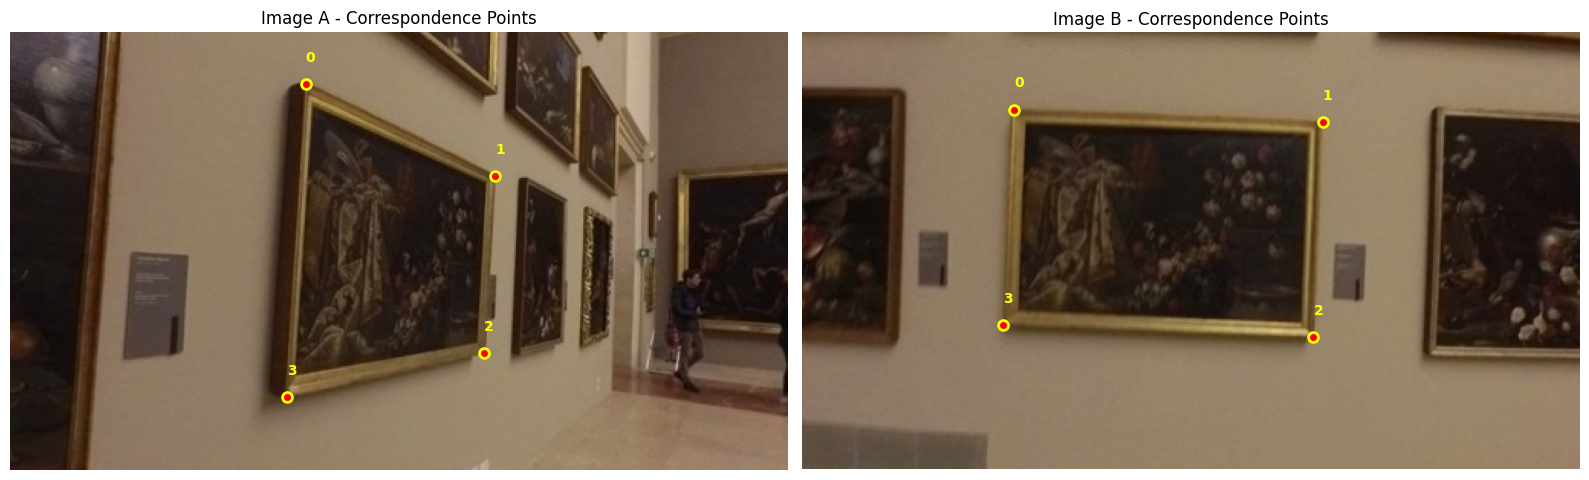

Correspondence points:
Point A: [[193.0, 34.0], [317.0, 94.0], [310.0, 210.0], [181.0, 239.0]]
Point B: [[138.0, 50.0], [340.0, 58.0], [334.0, 199.0], [131.0, 191.0]]


In [35]:
# Visualize corresponding points on both images
import matplotlib.pyplot as plt

# Define the correspondence points
point_a = np.array([[193, 34], [317, 94], [310, 210], [181, 239]], dtype=np.float32)
point_b = np.array([[138, 50], [340, 58], [334, 199], [131, 191]], dtype=np.float32)

# Convert from CHW to HWC for visualization
im_a_display = np.transpose(im_a, (1, 2, 0)).astype(np.uint8)
im_b_display = np.transpose(im_b, (1, 2, 0)).astype(np.uint8)

# Create figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot image A with its points
axes[0].imshow(im_a_display)
axes[0].scatter(point_a[:, 0], point_a[:, 1], c='red', s=50, marker='o', edgecolors='yellow', linewidth=2)
axes[0].set_title("Image A - Correspondence Points")
axes[0].axis('off')

# Add text labels for each point
for i, pt in enumerate(point_a):
    axes[0].text(pt[0], pt[1]-15, str(i), color='yellow', fontsize=10, weight='bold')

# Plot image B with its points
axes[1].imshow(im_b_display)
axes[1].scatter(point_b[:, 0], point_b[:, 1], c='red', s=50, marker='o', edgecolors='yellow', linewidth=2)
axes[1].set_title("Image B - Correspondence Points")
axes[1].axis('off')

# Add text labels for each point
for i, pt in enumerate(point_b):
    axes[1].text(pt[0], pt[1]-15, str(i), color='yellow', fontsize=10, weight='bold')

plt.tight_layout()
plt.show()

print("Correspondence points:")
print(f"Point A: {point_a.tolist()}")
print(f"Point B: {point_b.tolist()}")

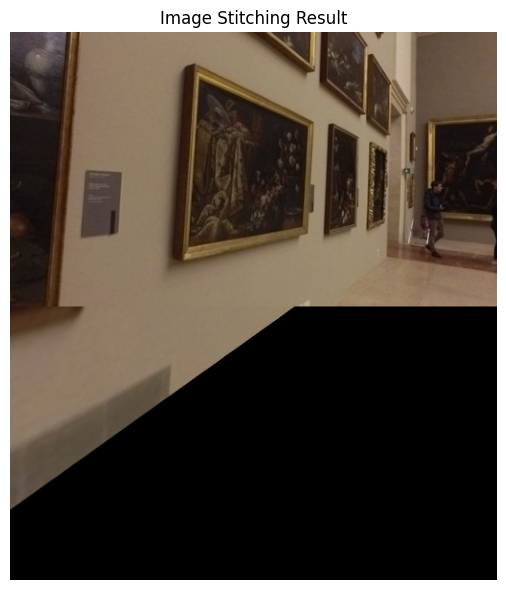

In [36]:
im_panorama = image_stitching(im_a, im_b)
import matplotlib.pyplot as plt

# Convert from CHW to HWC format for matplotlib display
im_panorama_display = np.transpose(im_panorama, (1, 2, 0)).astype(np.uint8)

plt.figure(figsize=(15, 6))
plt.imshow(im_panorama_display)
plt.title("Image Stitching Result")
plt.axis('off')
plt.tight_layout()
plt.show()